In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
import pandas as pd
import seaborn as sns
import os
import sys
import pickle

In [ ]:
data_directory = '/mnt/f/Behavioural_Data/Bpod_data/'
experiment_name = 'D-AP5-Chronic-Infusion-SP120-137_Aug23_Analysis'
data_path = os.path.join(data_directory, experiment_name)
save_path = os.path.join(data_path, 'Figures_and_csv')
if not os.path.exists(save_path):
    os.makedirs(save_path)

In [15]:
# list all the .pkl files in the current directory

pkl_files = [file for file in os.listdir(data_path) if file.endswith('.pkl')]

print(pkl_files)

['D-AP5-Chronic-Infusion-SP120-137_Aug23_dataframe.pkl']


In [16]:
# list pickle files in the data_path and load them as dictionaries
data_file = os.path.join(data_path, pkl_files[0])
with open(data_file, 'rb') as f:
    data = pickle.load(f)
print(data.keys())

Index(['AnimalID', 'ExperimentalGroup', 'SessionTime', 'FullSessionTime',
       'Protocol', 'Stimulation', 'Muscimol', 'RewardChange',
       'RewardChangeBlock', 'CenterPortDuration', 'Contingency',
       'RewardAmount', 'PunishDelay', 'Punish', 'BiasCorrection', 'TrialIndex',
       'TrialHighPerc', 'Outcomes', 'OptoStim', 'FirstPokeCorrect',
       'FirstPoke', 'TrialSide', 'TrialSequence', 'ResponseTime',
       'TrialStartTimestamp', 'CumulativePerformance', 'SwitchSide',
       'PreviousChoice', 'TrialEvents', 'TrialStates', 'FullGUI', 'SessionID',
       'ITIs', 'CumulativeTrialNumber', 'CumulativeTrialNumberByProtocol',
       'CurrentPastPerformance20', 'CurrentPastPerformance100',
       'NoOfCenterPokes', 'MiddleWaitTime', 'TrialInitiationTime', 'RightBias',
       'TrialsSpeed', 'PrevTrialSuccess'],
      dtype='object')


In [17]:
# convert the dictionary to a dataframe
df = pd.DataFrame(data)
df.head()

,AnimalID,ExperimentalGroup,SessionTime,FullSessionTime,Protocol,Stimulation,Muscimol,RewardChange,RewardChangeBlock,CenterPortDuration,...,CumulativeTrialNumber,CumulativeTrialNumberByProtocol,CurrentPastPerformance20,CurrentPastPerformance100,NoOfCenterPokes,MiddleWaitTime,TrialInitiationTime,RightBias,TrialsSpeed,PrevTrialSuccess
0,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,1,1.0,NaN,NaN,1,0.036407,290.7158,NaN,NaN,NaN
14,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,2,2.0,NaN,NaN,1,0.210900,NaN,NaN,NaN,0.0
17,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,3,3.0,NaN,NaN,1,0.349400,38.5954,NaN,1.313154,1.0
27,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,4,4.0,NaN,NaN,1,0.063000,49.1914,NaN,1.756277,1.0
34,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,5,5.0,NaN,NaN,1,0.058800,8.2032,NaN,1.751116,1.0


In [18]:
df.info()
# if 'SP126' in df['AnimalID'].tolist():
#     print("'SP126' exists in the original dataframe.")
# else:
#     print("'SP126' does not exist in the original dataframe.")


<class 'pandas.core.frame.DataFrame'>
Int64Index: 164456 entries, 0 to 179222
Data columns (total 43 columns):
AnimalID                           164456 non-null object
ExperimentalGroup                  164456 non-null object
SessionTime                        164456 non-null object
FullSessionTime                    164456 non-null datetime64[ns]
Protocol                           164456 non-null object
Stimulation                        164456 non-null object
Muscimol                           164456 non-null object
RewardChange                       164456 non-null object
RewardChangeBlock                  164456 non-null int64
CenterPortDuration                 164456 non-null float64
Contingency                        164456 non-null int64
RewardAmount                       164456 non-null int64
PunishDelay                        164456 non-null float64
Punish                             164456 non-null object
BiasCorrection                     164456 non-null int64
TrialIndex   

### First saline session after chronic D-AP5 treatment: Task performance (%)

In [19]:
dates = df['FullSessionTime'].unique()
# print(dates)

In [20]:
# Provide AnimalIDs and dates for analysis
# refer to https://docs.google.com/spreadsheets/d/1ySelwJm3NSk8DC0BfwePGAgFHRN1nxvFOZ7CzhhhI9k/edit?usp=sharing
# D-AP5 and slaine dates according to animalIDs
# Note: For the D-AP5 group it needs to be manually checked as not all mice were stopped D-AP5 infusion once they reached 3000 trials

mice = ['SP120', 'SP121', 'SP122', 'SP124', 'SP126'] 
saline_dates = ['2023-06-07', '2023-06-09', '2023-06-08', '2023-06-05', '2023-06-05']
AP5_dates = ['2023-06-06', '2023-06-08', '2023-06-07', '2023-06-04', '2023-06-04']

# exctract data from saline and AP5 groups from df and save them as separate dataframes
# e.g. all rows with AnimalID == 'SP120' and FullSessionTime == '2023-06-07' will be saved in saline_df
# and all rows with AnimalID == 'SP120' and FullSessionTime == '2023-06-06' will be saved in AP5_df
# this will be done for all mice and dates in the saline_dates and AP5_dates lists
# the entries are corresponding to the same mouse and date in the saline_dates and AP5_dates lists

saline_df = pd.DataFrame()
AP5_df = pd.DataFrame()

for mouse, saline_date, AP5_date in zip(mice, saline_dates, AP5_dates):
    # print(mouse, saline_date, AP5_date) # check if the loop is working correctly
    # convert df['FullSessionTime'] to str to be able to compare it with the dates in the saline_dates and AP5_dates lists
    # take the first 10 characters of the string (yyyy-mm-dd)
    sessions = df['FullSessionTime'].astype(str).str[:10]
    saline_df = saline_df.append(df[(df['AnimalID'] == mouse) & (sessions == saline_date)])
    AP5_df = AP5_df.append(df[(df['AnimalID'] == mouse) & (sessions == AP5_date)])


## Some checks
# saline_df.head()
# AP5_df.head()
# print(saline_df['AnimalID'].unique())
# print(AP5_df['AnimalID'].unique())
# print(saline_df['FullSessionTime'].unique())
# print(AP5_df['FullSessionTime'].unique())


# append saline and AP5 dataframes with column Treatment. Assign 'Saline' to saline_df and 'D-AP5' to AP5_df

saline_df['Treatment'] = 'Saline'
AP5_df['Treatment'] = 'D-AP5'

# concatenate saline_df and AP5_df into one dataframe
# this will be used for plotting and statistical analysis

df_post_AP5 = pd.concat([saline_df, AP5_df])
# df_post_AP5.head()

In [21]:
def perf_window_calculator(firstpokecorrect, window):
    """
    Calculate the performance of the last X trials
    This is a function written by Hernando and used in APE paper (Greenstreet et al., 2022 for analysis)
    """
    perf_window = np.full(len(firstpokecorrect), np.nan)
    for i in range(len(perf_window)):
        if i < window:
            # For the first window-1 trials, dynamically adjust the window size
            current_window_size = i + 1
            perf_window[i] = np.nansum(firstpokecorrect[:i+1]) / current_window_size * 100
        else:
            perf_window[i] = np.nansum(firstpokecorrect[i - window + 1: i + 1]) / window * 100
    return perf_window

In [22]:
mice_to_remove = ['SP124']
# remove mice in the list mice_to_remove from the dataframe df_post_AP5
df_post_AP5 = df_post_AP5[~df_post_AP5['AnimalID'].isin(mice_to_remove)]


  Treatment AnimalID  Performance
0     D-AP5    SP120    81.869688
1     D-AP5    SP121    86.695279
2     D-AP5    SP122    76.190476
3     D-AP5    SP126    66.200000
4    Saline    SP120    85.439560
5    Saline    SP121    80.833333
6    Saline    SP122    80.503145
7    Saline    SP126    70.276008
Data saved to '/mnt/f/Behavioural_Data/Bpod_data/D-AP5-Chronic-Infusion-SP120-137_Aug23_Analysis/Figures_and_cvs/performance_data.csv'
t-statistic:  0.27993030135967406
p-value:  0.7889313114122491


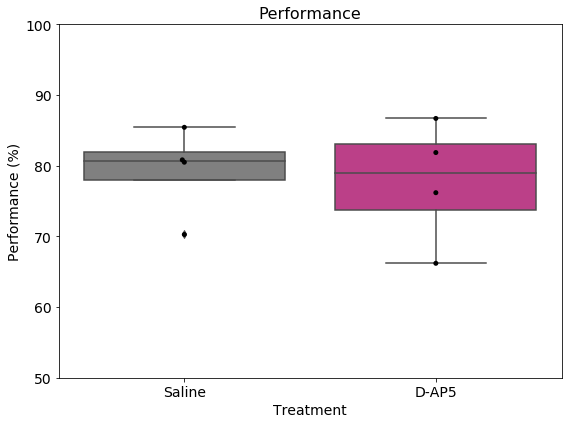

In [23]:

# plot Task Perfomrance in y-axis and grouped by Treatment in x-axis for df_post_AP5
# Perfomrance is calculated as the percentage of FirstPokeCorrect trials in the entire session
# calculate the percentage of firstpokecorrect trials in the entire session
# use formula df_post_AP5['FirstPokeCorrect'].sum() / len(df_post_AP5) * 100

# Calculate the percentage of firstpokecorrect trials in the entire session
perf = df_post_AP5.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].sum() / df_post_AP5.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].count() * 100
perf = perf.reset_index()
perf.columns = ['Treatment', 'AnimalID', 'Performance']
print(perf)

# Save the performance data to a CSV file in the save_path directory
csv_filename = os.path.join(save_path, 'performance_data.csv')
perf.to_csv(csv_filename, index=False)
print(f"Data saved to '{csv_filename}'")

# perform student's t-test for saline and AP5 groups
t, p = ttest_ind(perf[perf['Treatment'] == 'Saline']['Performance'], perf[perf['Treatment'] == 'D-AP5']['Performance'])
print('t-statistic: ', t)
print('p-value: ', p)

# plot the performance for the saline and AP5 groups
group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b'}
group_order = ['Saline', 'D-AP5']

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Treatment', y='Performance', data=perf, palette=group_colors, order=group_order, ax=ax)
# plot swarmplot besides the boxplot, avoid overlapping points
sns.swarmplot(x='Treatment', y='Performance', data=perf, color='black', order=group_order, ax=ax)

ax.set_xlabel('Treatment', fontsize=14)
ax.set_ylabel('Performance (%)', fontsize=14)
ax.set_ylim(50, 100)
ax.tick_params(labelsize=14)
ax.set_title('Performance', fontsize=16)
plt.tight_layout()
plt.show()


### Here plot cumulative performance comparision between saline, D-AP5 and olanzapine infusion in expert mice performing COT task

In [24]:

if 'SP126' in df['AnimalID'].tolist():
    print("'SP126' exists in the original dataframe.")
else:
    print("'SP126' does not exist in the original dataframe.")


'SP126' exists in the original dataframe.


In [25]:
animals = ['SP120', 'SP121', 'SP122', 'SP124', 'SP126']
print(animals)

saline_dates = ['2023-07-21', '2023-07-25', '2023-07-31', '2023-08-01']
dap5_dates = ['2023-07-24', '2023-07-26']
olanzapine_dates = ['2023-08-03']

['SP120', 'SP121', 'SP122', 'SP124', 'SP126']


In [26]:
# exctract data from saline and AP5 groups from df and save them as separate dataframes
# e.g. all rows with AnimalID == 'SP120' and FullSessionTime == '2023-06-07' will be saved in saline_df

expert_saline_df = pd.DataFrame()
expert_dap5_df = pd.DataFrame()
expert_olanzapine_df = pd.DataFrame()

for animal in animals:
    # print(mouse, saline_date, AP5_date) # check if the loop is working correctly
    # convert df['FullSessionTime'] to str to be able to compare it with the dates in the saline_dates and AP5_dates lists
    # take the first 10 characters of the string (yyyy-mm-dd)
    # saline sessions are combination of all dates in saline_date and so on for AP5 and olanzapine

    sessions = df['FullSessionTime'].astype(str).str[:10]
    expert_saline_df = expert_saline_df.append(df[(df['AnimalID'] == animal) & (sessions.isin(saline_dates))])
    expert_dap5_df = expert_dap5_df.append(df[(df['AnimalID'] == animal) & (sessions.isin(dap5_dates))])
    expert_olanzapine_df = expert_olanzapine_df.append(df[(df['AnimalID'] == animal) & (sessions.isin(olanzapine_dates))])
    

# append saline and AP5 dataframes with column Treatment. Assign 'Saline' to saline_df, 'D-AP5' to AP5_df, and 'Olanzapine' to olanzapine_df

expert_saline_df['Treatment'] = 'Saline'
expert_dap5_df['Treatment'] = 'D-AP5'
expert_olanzapine_df['Treatment'] = 'Olanzapine'

# concatenate saline_df and AP5_df into one dataframe

expert_df = pd.concat([expert_saline_df, expert_dap5_df, expert_olanzapine_df])

# expert_df.head()
print(expert_df['AnimalID'].unique())

['SP120' 'SP121' 'SP122' 'SP126']


In [27]:
mice_to_remove = ['SP124']
# remove mice in the list mice_to_remove from the dataframe df_post_AP5

expert_df = expert_df[~expert_df['AnimalID'].isin(mice_to_remove)]


['SP120' 'SP121' 'SP122' 'SP126']
     Treatment AnimalID  Performance
0        D-AP5    SP120    88.159112
1        D-AP5    SP121    90.394511
2        D-AP5    SP122    84.022258
3        D-AP5    SP126    86.900369
4   Olanzapine    SP120    86.842105
5   Olanzapine    SP121    89.761905
6   Olanzapine    SP122    87.475915
7   Olanzapine    SP126    91.176471
8       Saline    SP120    87.864823
9       Saline    SP121    90.162602
10      Saline    SP122    82.993197
11      Saline    SP126    89.989236
Data saved to '/mnt/f/Behavioural_Data/Bpod_data/D-AP5-Chronic-Infusion-SP120-137_Aug23_Analysis/Figures_and_cvs/expert_performance_data.csv'
Saline vs D-AP5
t-statistic:  0.17962089530075726
p-value:  0.8633627405596723


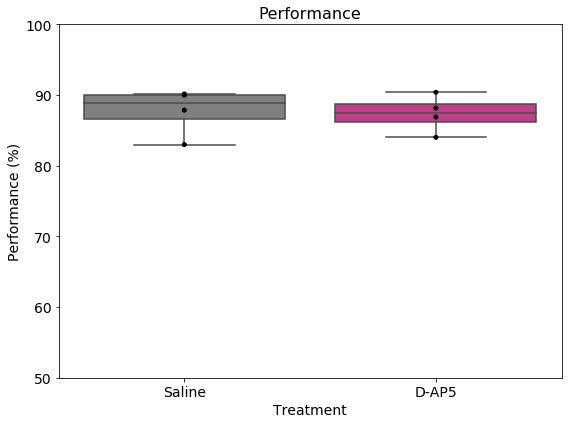

In [28]:
# plot Task Perfomrance in y-axis and grouped by Treatment in x-axis for expert_df
# Perfomrance is calculated as the percentage of FirstPokeCorrect trials in the entire session
# calculate the percentage of firstpokecorrect trials in the entire session
# use formula df_post_AP5['FirstPokeCorrect'].sum() / len(df_post_AP5) * 100

# Calculate the percentage of firstpokecorrect trials in the entire session
expert_perf = expert_df.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].sum() / expert_df.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].count() * 100
expert_perf = expert_perf.reset_index()
expert_perf.columns = ['Treatment', 'AnimalID', 'Performance']
print(expert_df['AnimalID'].unique())
print(expert_perf)

# Filter out Olanzapine for saving and plotting
expert_perf_filtered = expert_perf[expert_perf['Treatment'].isin(['Saline', 'D-AP5'])].copy()

# Save the filtered performance data to a CSV file in the save_path directory
csv_filename = os.path.join(save_path, 'expert_performance_data.csv')
expert_perf_filtered.to_csv(csv_filename, index=False)
print(f"Data saved to '{csv_filename}'")

# Perform t-test for Saline vs D-AP5 only
print('Saline vs D-AP5')
t, p = ttest_ind(expert_perf[expert_perf['Treatment'] == 'Saline']['Performance'], 
                 expert_perf[expert_perf['Treatment'] == 'D-AP5']['Performance'])
print('t-statistic: ', t)
print('p-value: ', p)

# Plot only Saline and D-AP5 groups
group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b'}
group_order = ['Saline', 'D-AP5']

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Treatment', y='Performance', data=expert_perf_filtered, 
            palette=group_colors, order=group_order, ax=ax)
# Plot swarmplot besides the boxplot, avoid overlapping points
sns.swarmplot(x='Treatment', y='Performance', data=expert_perf_filtered, 
              color='black', order=group_order, ax=ax)

ax.set_xlabel('Treatment', fontsize=14)
ax.set_ylabel('Performance (%)', fontsize=14)
ax.set_ylim(50, 100)
ax.tick_params(labelsize=14)
ax.set_title('Performance', fontsize=16)
plt.tight_layout()
plt.show()